# Mejor Modelo — Random Forest

Este notebook recoge el pipeline completo para generar las predicciones finales sobre el conjunto de test de Kaggle. El modelo elegido es **Random Forest**, seleccionado tras comparar todos los modelos evaluados en `supervised.ipynb` tanto en test interno como en la competición de Kaggle, donde obtuvo el mejor score(0.857).

El flujo es el siguiente:

1. **Preprocesado** de `salario.csv`: limpieza, codificación y normalización con las mismas transformaciones aplicadas en `preprocess.ipynb`.
2. **División** train / val / test con las mismas proporciones y semilla (`random_state=42`).
3. **Tratamiento del desbalanceo** con TomekLinks exclusivamente sobre `X_train`.
4. **Búsqueda de hiperparámetros** con `GridSearchCV` (5 folds) sobre train+val.
5. **Evaluación interna** sobre `X_test` (nunca visto en ningún paso anterior).
6. **Preprocesado** de `salario_test.csv` con el mismo `scaler` ajustado en train.
7. **Generación** de `test_labels_rf.csv` en el formato requerido por Kaggle.
8. **Análisis de interpretabilidad** mediante importancia de features.

## 1. Imports y carga de datos

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, make_scorer
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

cols = ['edad','origen_trabajo','estudios','estado_civil','trabajo',
        'posicion_familiar','etnia','sexo','ganancias_inversiones',
        'perdidas_inversiones','horas_trabajo_semana','pais_origen','salario']

df = pd.read_csv('salario.csv', names=cols, header=0)
print(f'Dataset cargado: {df.shape[0]} instancias, {df.shape[1]} columnas')

Dataset cargado: 27998 instancias, 13 columnas


## 2. Preprocesado

Aplicamos exactamente las mismas transformaciones definidas en `preprocess.ipynb`:

- **Valores faltantes**: los `?` de `origen_trabajo`, `trabajo` y `pais_origen` se imputan por moda o categoría `Unknown` según la distribución de cada columna.
- **Variables numéricas**: `edad` se normaliza dividiendo entre 100; `ganancias_inversiones` y `perdidas_inversiones` se discretizan mediante binning; `horas_trabajo_semana` se estandariza con `StandardScaler`.
- **Variables binarias**: `sexo` y `salario` se mapean directamente a 0/1.
- **Variables categóricas**: se aplica One-Hot Encoding con categorías fijas en el mismo orden que en `preprocess.ipynb`, garantizando que el espacio de features del conjunto de test sea idéntico al de entrenamiento.

El `scaler` se ajusta (`fit_transform`) sobre `salario.csv` y se reutiliza con `transform` sobre `salario_test.csv` para evitar data leakage.

In [2]:
# Limpieza de valores faltantes
df.loc[df['origen_trabajo'] == ' ?', 'origen_trabajo'] = np.nan
df.loc[df['trabajo']        == ' ?', 'trabajo']        = np.nan
df.loc[df['pais_origen']    == ' ?', 'pais_origen']    = np.nan
df['origen_trabajo'] = df['origen_trabajo'].fillna(' Private')
df['trabajo']        = df['trabajo'].fillna(' Unknown')
df['pais_origen']    = df['pais_origen'].fillna(' United-States')
df.drop_duplicates(inplace=True)

# Transformaciones numéricas y binarias
df['edad']    = df['edad'] / 100
df['sexo']    = df['sexo'].map({' Hombre': 0, ' Mujer': 1})
df['salario'] = df['salario'].map({' <=50K': 0, ' >50K': 1})

df['ganancias_inversiones'] = pd.cut(
    df['ganancias_inversiones'],
    bins=[-1, 0, 5000, 99998, np.inf], labels=[0, 1, 2, 3]
).astype(int)

df['perdidas_inversiones'] = pd.cut(
    df['perdidas_inversiones'],
    bins=[-1, 0, 1900, np.inf], labels=[0, 1, 2]
).astype(int)

# StandardScaler ajustado sobre salario.csv — se reutilizará en salario_test.csv
scaler = StandardScaler()
df['horas_trabajo_semana'] = scaler.fit_transform(df[['horas_trabajo_semana']])

# One-Hot Encoding con categorías fijas
orden_origen_trabajo = [' Private',' Self-emp-not-inc',' Self-emp-inc',
                        ' Federal-gov',' Local-gov',' State-gov',
                        ' Without-pay',' Never-worked']
orden_estudios       = [' Preschool',' 1st-4th',' 5th-6th',' 7th-8th',' 9th',
                        ' 10th',' 11th',' 12th',' HS-grad',' Some-college',
                        ' Assoc-acdm',' Assoc-voc',' Bachelors',' Masters',
                        ' Prof-school',' Doctorate']
orden_estado_civil   = [' Never-married',' Married-civ-spouse',' Divorced',
                        ' Married-spouse-absent',' Separated',
                        ' Married-AF-spouse',' Widowed']
orden_trabajo        = [' Adm-clerical',' Exec-managerial',' Handlers-cleaners',
                        ' Prof-specialty',' Other-service',' Sales',
                        ' Transport-moving',' Farming-fishing',' Machine-op-inspct',
                        ' Tech-support',' Craft-repair',' Protective-serv',
                        ' Armed-Forces',' Priv-house-serv',' Unknown']
orden_familiar       = [' No-en-familia',' Marido',' Mujer',
                        ' Hijo-unico',' Soltero-a',' Otro-familiar']
orden_etnia          = [' Blanco',' Negro',' Asiatico-Pacifico-Isleno',
                        ' Amerindio-esquimal',' Otro']
orden_pais           = [' United-States',' Cuba',' Jamaica',' India',' Mexico',
                        ' Puerto-Rico',' Honduras',' England',' Canada',' Germany',
                        ' Iran',' Philippines',' Poland',' Columbia',' Cambodia',
                        ' Thailand',' Ecuador',' Laos',' Taiwan',' Haiti',
                        ' Portugal',' Dominican-Republic',' El-Salvador',' France',
                        ' Guatemala',' Italy',' China',' South',' Japan',
                        ' Yugoslavia',' Peru',' Outlying-US(Guam-USVI-etc)',
                        ' Scotland',' Trinadad&Tobago',' Greece',' Nicaragua',
                        ' Vietnam',' Hong',' Ireland',' Hungary',
                        ' Holand-Netherlands']

def ohe(df_in, col, orden, prefijo):
    dummies = pd.get_dummies(
        pd.Categorical(df_in[col], categories=orden), dtype=int
    )
    dummies.columns = [f'{prefijo}_{c.strip()}' for c in orden]
    return dummies.set_index(df_in.index)

df_expanded = pd.concat([
    df[['edad','sexo','ganancias_inversiones',
        'perdidas_inversiones','horas_trabajo_semana']],
    ohe(df, 'origen_trabajo',    orden_origen_trabajo, 'origen_trabajo'),
    ohe(df, 'estudios',          orden_estudios,       'estudios'),
    ohe(df, 'estado_civil',      orden_estado_civil,   'estado_civil'),
    ohe(df, 'trabajo',           orden_trabajo,        'trabajo'),
    ohe(df, 'posicion_familiar', orden_familiar,       'posicion_familiar'),
    ohe(df, 'etnia',             orden_etnia,          'etnia'),
    ohe(df, 'pais_origen',       orden_pais,           'pais_origen'),
], axis=1)

Y = df['salario']
print(f'Dataset expandido: {df_expanded.shape[1]} features')

Dataset expandido: 103 features


## 3. División train / val / test

Mismas proporciones y semilla que en `supervised.ipynb` (70/15/15, `random_state=42`), garantizando que `X_test` es exactamente el mismo conjunto sobre el que se evaluaron todos los modelos en la fase comparativa.

In [3]:
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    df_expanded, Y, test_size=0.15, shuffle=True, random_state=42
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.176, shuffle=True, random_state=42
)

print(f'Train:      {X_train.shape[0]} instancias')
print(f'Validación: {X_val.shape[0]} instancias')
print(f'Test:       {X_test.shape[0]} instancias')

Train:      17664 instancias
Validación: 3773 instancias
Test:       3784 instancias


## 4. Selección de features

Se aplica el subconjunto de 74 features seleccionadas por el **método filtro** en `preprocess.ipynb`, que fue el método elegido como base del dataset procesado por su independencia del clasificador y su capacidad de generalización.

In [4]:
features_filtro = [
    'edad', 'horas_trabajo_semana', 'sexo', 'ganancias_inversiones',
    'perdidas_inversiones', 'estado_civil_Married-civ-spouse',
    'posicion_familiar_Marido', 'estado_civil_Never-married',
    'posicion_familiar_Hijo-unico', 'trabajo_Exec-managerial',
    'trabajo_Prof-specialty', 'estudios_Masters',
    'posicion_familiar_No-en-familia', 'estudios_Prof-school',
    'estudios_Bachelors', 'trabajo_Other-service',
    'posicion_familiar_Soltero-a', 'origen_trabajo_Self-emp-inc',
    'estudios_Doctorate', 'estado_civil_Divorced',
    'posicion_familiar_Mujer', 'estudios_HS-grad', 'etnia_Negro',
    'posicion_familiar_Otro-familiar', 'estudios_11th',
    'trabajo_Adm-clerical', 'trabajo_Handlers-cleaners',
    'estado_civil_Separated', 'estado_civil_Widowed', 'trabajo_Unknown',
    'estudios_10th', 'pais_origen_Mexico', 'origen_trabajo_Private',
    'trabajo_Machine-op-inspct', 'estudios_7th-8th', 'estudios_9th',
    'origen_trabajo_Federal-gov', 'estudios_Some-college',
    'trabajo_Farming-fishing', 'estudios_5th-6th',
    'estado_civil_Married-spouse-absent', 'estudios_12th',
    'trabajo_Priv-house-serv', 'etnia_Otro', 'etnia_Blanco',
    'estudios_1st-4th', 'etnia_Amerindio-esquimal', 'trabajo_Tech-support',
    'origen_trabajo_Self-emp-not-inc', 'origen_trabajo_Local-gov',
    'pais_origen_Guatemala', 'estudios_Preschool', 'trabajo_Protective-serv',
    'pais_origen_Dominican-Republic', 'trabajo_Sales',
    'pais_origen_Columbia', 'pais_origen_El-Salvador',
    'pais_origen_Puerto-Rico', 'pais_origen_Vietnam',
    'origen_trabajo_State-gov', 'trabajo_Transport-moving',
    'pais_origen_Iran', 'pais_origen_Taiwan', 'pais_origen_Canada',
    'pais_origen_Peru', 'pais_origen_Haiti', 'pais_origen_Italy',
    'pais_origen_Japan', 'pais_origen_Nicaragua', 'pais_origen_India',
    'pais_origen_Germany', 'pais_origen_France',
    'pais_origen_United-States', 'pais_origen_England'
]

X_train_f = X_train[features_filtro].values
X_val_f   = X_val[features_filtro].values
X_test_f  = X_test[features_filtro].values

print(f'Features seleccionadas: {len(features_filtro)}')

Features seleccionadas: 74


## 5. Tratamiento del desbalanceo — TomekLinks

El dataset presenta un desbalanceo moderado (~75% `<=50K` / ~25% `>50K`). Se aplica **TomekLinks** para eliminar instancias fronterizas o ruidosas de la clase mayoritaria, limpiando la frontera de decisión sin generar datos sintéticos.

TomekLinks se aplica **exclusivamente sobre `X_train`** para evitar que la limpieza esté influida por instancias de validación o test.

In [5]:
tl = TomekLinks(n_jobs=-1)
X_train_tl, Y_train_tl = tl.fit_resample(X_train_f, Y_train)

print(f'Train original:   {dict(zip(*np.unique(Y_train, return_counts=True)))}')
print(f'Train TomekLinks: {dict(zip(*np.unique(Y_train_tl, return_counts=True)))}')
print(f'Instancias eliminadas: {len(Y_train) - len(Y_train_tl)}')

Train original:   {np.int64(0): np.int64(13274), np.int64(1): np.int64(4390)}
Train TomekLinks: {np.int64(0): np.int64(12532), np.int64(1): np.int64(4390)}
Instancias eliminadas: 742


## 6. Búsqueda de hiperparámetros — GridSearchCV

Se buscan los mejores hiperparámetros del Random Forest mediante `GridSearchCV` con 5 folds, usando **F1 weighted** como métrica de optimización. El ajuste se realiza sobre la combinación de `X_train_tl` y `X_val`, maximizando los datos disponibles para la búsqueda sin comprometer la evaluación final sobre `X_test`.

Los hiperparámetros explorados son los mismos que en `supervised.ipynb`, con un grid ligeramente ampliado en `n_estimators` para aprovechar el mayor volumen de datos de entrenamiento.

In [6]:
X_search = np.vstack([X_train_tl, X_val_f])
Y_search = np.concatenate([Y_train_tl, Y_val.values])

scorer = make_scorer(f1_score, average='weighted')

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'criterion':        ['gini', 'entropy'],
        'n_estimators':     [100, 200, 300],
        'max_features':     ['sqrt', 'log2'],
        'max_depth':        [10, 20, None],
        'min_samples_leaf': [1, 5, 10],
    },
    cv=5, scoring=scorer, n_jobs=-1
).fit(X_search, Y_search)

best_rf = grid.best_estimator_

print(f'Mejores hiperparámetros:')
print(f'  criterion:        {grid.best_params_["criterion"]}')
print(f'  n_estimators:     {grid.best_params_["n_estimators"]}')
print(f'  max_features:     {grid.best_params_["max_features"]}')
print(f'  max_depth:        {grid.best_params_["max_depth"]}')
print(f'  min_samples_leaf: {grid.best_params_["min_samples_leaf"]}')
print(f'F1 weighted CV:     {grid.best_score_:.4f}')

Mejores hiperparámetros:
  criterion:        gini
  n_estimators:     300
  max_features:     sqrt
  max_depth:        20
  min_samples_leaf: 1
F1 weighted CV:     0.8572


## 7. Evaluación interna sobre X_test

Evaluamos el modelo sobre `X_test`, el 15% del dataset que no ha participado en ningún paso anterior — ni en el entrenamiento, ni en la búsqueda de hiperparámetros, ni en TomekLinks. Este resultado es la referencia honesta del rendimiento del modelo antes de aplicarlo al conjunto de Kaggle.

In [7]:
pred_test = best_rf.predict(X_test_f)

print(f'F1 weighted test interno (θ=0.5): {f1_score(Y_test, pred_test, average="weighted"):.4f}')
print(classification_report(Y_test, pred_test, target_names=['<=50K', '>50K']))

F1 weighted test interno (θ=0.5): 0.8376
              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.90      2918
        >50K       0.67      0.60      0.63       866

    accuracy                           0.84      3784
   macro avg       0.78      0.76      0.77      3784
weighted avg       0.84      0.84      0.84      3784



## 8. Preprocesado de salario_test.csv

Se aplican exactamente las mismas transformaciones que sobre `salario.csv`. El punto crítico es el escalado de `horas_trabajo_semana`: se usa `scaler.transform()` y no `fit_transform()`, reutilizando el scaler ajustado sobre los datos de entrenamiento. Reajustar el scaler sobre el conjunto de test introduciría data leakage.

In [8]:
cols_test = ['edad','origen_trabajo','estudios','estado_civil','trabajo',
             'posicion_familiar','etnia','sexo','ganancias_inversiones',
             'perdidas_inversiones','horas_trabajo_semana','pais_origen']

df_test = pd.read_csv('salario_test.csv', names=cols_test, header=0)
ids = np.arange(1, len(df_test) + 1)

df_test.loc[df_test['origen_trabajo'] == ' ?', 'origen_trabajo'] = np.nan
df_test.loc[df_test['trabajo']        == ' ?', 'trabajo']        = np.nan
df_test.loc[df_test['pais_origen']    == ' ?', 'pais_origen']    = np.nan
df_test['origen_trabajo'] = df_test['origen_trabajo'].fillna(' Private')
df_test['trabajo']        = df_test['trabajo'].fillna(' Unknown')
df_test['pais_origen']    = df_test['pais_origen'].fillna(' United-States')

df_test['edad'] = df_test['edad'] / 100
df_test['sexo'] = df_test['sexo'].map({' Hombre': 0, ' Mujer': 1})

df_test['ganancias_inversiones'] = pd.cut(
    df_test['ganancias_inversiones'],
    bins=[-1, 0, 5000, 99998, np.inf], labels=[0, 1, 2, 3]
).astype(int)

df_test['perdidas_inversiones'] = pd.cut(
    df_test['perdidas_inversiones'],
    bins=[-1, 0, 1900, np.inf], labels=[0, 1, 2]
).astype(int)

# transform() — NO fit_transform()
df_test['horas_trabajo_semana'] = scaler.transform(df_test[['horas_trabajo_semana']])

df_test_expanded = pd.concat([
    df_test[['edad','sexo','ganancias_inversiones',
             'perdidas_inversiones','horas_trabajo_semana']],
    ohe(df_test, 'origen_trabajo',    orden_origen_trabajo, 'origen_trabajo'),
    ohe(df_test, 'estudios',          orden_estudios,       'estudios'),
    ohe(df_test, 'estado_civil',      orden_estado_civil,   'estado_civil'),
    ohe(df_test, 'trabajo',           orden_trabajo,        'trabajo'),
    ohe(df_test, 'posicion_familiar', orden_familiar,       'posicion_familiar'),
    ohe(df_test, 'etnia',             orden_etnia,          'etnia'),
    ohe(df_test, 'pais_origen',       orden_pais,           'pais_origen'),
], axis=1)

X_kaggle = df_test_expanded[features_filtro].values
print(f'salario_test.csv preprocesado: {X_kaggle.shape}')

salario_test.csv preprocesado: (4563, 74)


## 9. Predicción y generación de test_labels.csv

Se generan las predicciones sobre el conjunto de test de Kaggle y se guardan en el formato requerido por la competición.

test_labels_rf.csv generado correctamente.
Total predicciones: 4563
Distribución predicha:
Salario
<=50K    3577
>50K      986
Name: count, dtype: int64

Primeras filas:
   ID Salario
0   1   <=50K
1   2   <=50K
2   3   <=50K
3   4   <=50K
4   5   <=50K


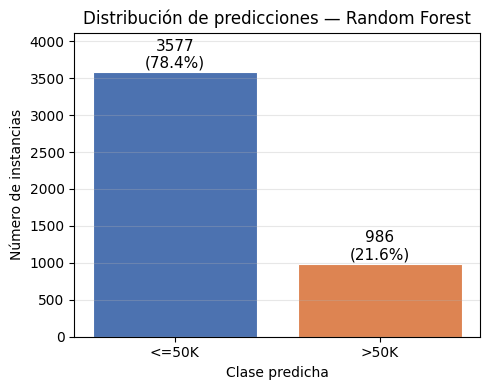

In [9]:
pred_kaggle       = best_rf.predict(X_kaggle)
pred_kaggle_label = np.where(pred_kaggle == 0, '<=50K', '>50K')

submission = pd.DataFrame({'ID': ids, 'Salario': pred_kaggle_label})
submission.to_csv('test_labels_rf_def.csv', index=False)

print(f'test_labels_rf.csv generado correctamente.')
print(f'Total predicciones: {len(submission)}')
print(f'Distribución predicha:')
print(submission['Salario'].value_counts())
print(f'\nPrimeras filas:')
print(submission.head())

fig, ax = plt.subplots(figsize=(5, 4))
counts = submission['Salario'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f'{val}\n({val/len(submission)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)
ax.set_title('Distribución de predicciones — Random Forest')
ax.set_xlabel('Clase predicha')
ax.set_ylabel('Número de instancias')
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Análisis de interpretabilidad

Una de las ventajas del Random Forest frente a otros modelos como SVM o MLP es la disponibilidad de `feature_importances_`: la importancia media de cada feature a lo largo de todos los árboles, calculada como la reducción total de impureza Gini ponderada por el número de instancias que pasan por cada nodo.

Este análisis permite identificar qué variables tienen mayor peso en la decisión del modelo, aportando valor explicativo más allá del resultado numérico.

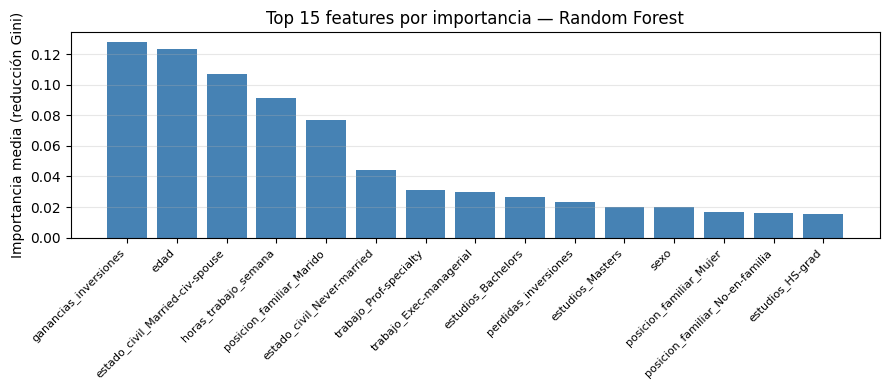

Top 10 features más importantes:
Feature                                        Importancia
──────────────────────────────────────────────────────────
ganancias_inversiones                               0.1278
edad                                                0.1231
estado_civil_Married-civ-spouse                     0.1067
horas_trabajo_semana                                0.0910
posicion_familiar_Marido                            0.0772
estado_civil_Never-married                          0.0442
trabajo_Prof-specialty                              0.0309
trabajo_Exec-managerial                             0.0302
estudios_Bachelors                                  0.0266
perdidas_inversiones                                0.0230


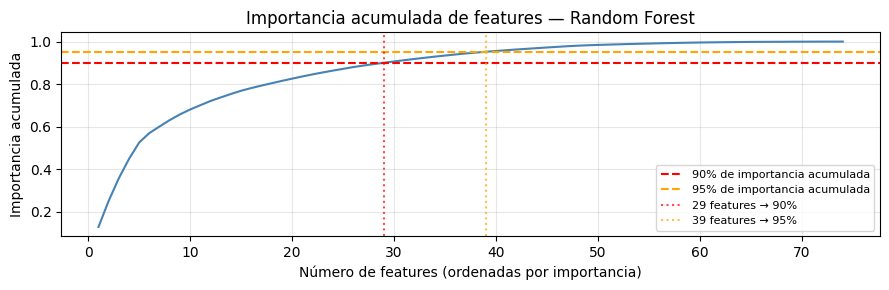


Con 29 features se explica el 90% de la importancia total.
Con 39 features se explica el 95% de la importancia total.


In [ ]:
importancias = best_rf.feature_importances_
indices      = importancias.argsort()[::-1]

#top 15 features
top_n = 15
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(top_n), importancias[indices[:top_n]], color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels(
    [features_filtro[i] for i in indices[:top_n]],
    rotation=45, ha='right', fontsize=8
)
ax.set_ylabel('Importancia media (reducción Gini)')
ax.set_title('Top 15 features por importancia — Random Forest')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#Tabla resumen top 10
print('Top 10 features más importantes:')
print(f'{"Feature":<45} {"Importancia":>12}')
print('─' * 58)
for i in indices[:10]:
    print(f'{features_filtro[i]:<45} {importancias[i]:>12.4f}')

#Porcentaje acumulado de importantcia
importancias_ord = importancias[indices]
acumulado        = np.cumsum(importancias_ord)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(1, len(acumulado) + 1), acumulado, color='steelblue')
ax.axhline(0.9, color='red', linestyle='--', label='90% de importancia acumulada')
ax.axhline(0.95, color='orange', linestyle='--', label='95% de importancia acumulada')
n_90  = np.searchsorted(acumulado, 0.90) + 1
n_95  = np.searchsorted(acumulado, 0.95) + 1
ax.axvline(n_90,  color='red',    linestyle=':', alpha=0.7, label=f'{n_90} features → 90%')
ax.axvline(n_95,  color='orange', linestyle=':', alpha=0.7, label=f'{n_95} features → 95%')
ax.set_xlabel('Número de features (ordenadas por importancia)')
ax.set_ylabel('Importancia acumulada')
ax.set_title('Importancia acumulada de features — Random Forest')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nCon {n_90} features se explica el 90% de la importancia total.')
print(f'Con {n_95} features se explica el 95% de la importancia total.')